# Prognoza zamówień e-commerce 

End-to-end pipeline forecastingowy na danych **Databricks Marketplace "Simulated Retail Customer Data"**.

**Tabele:** `databricks_simulated_retail_customer_data.v01.sales_orders`, `.sales`, `.customers`

| Parametr | Wartość |
| --- | --- |
| **Cel (target)** | `n_orders` — dzienna liczba unikalnych zamówień |
| **Granulacja** | 1 dzień — agregujemy wszystkie zamówienia z danego dnia do jednej wartości |
| **Holdout** | Ostatnie 14 dni — model trenujemy na wcześniejszych danych, a na końcowych 14 dniach mierzymy dokładność |

## 1. Data Explorer

W tej sekcji ładujemy dane źródłowe, konwertujemy czas zamówienia do daty, parsujemy JSON z listą produktów i budujemy podstawowy widok dzienny. Dzięki temu widać skalę danych, zakres dat oraz bazowe trendy zamówień i przychodu.

=== DATA EXPLORER ===
sales_orders : 4,074 rows
sales        : 360 rows
customers    : 28,813 rows
Date range : 2019-08-01 to 2019-11-14 (106 days)
Exploded line items: 8,137


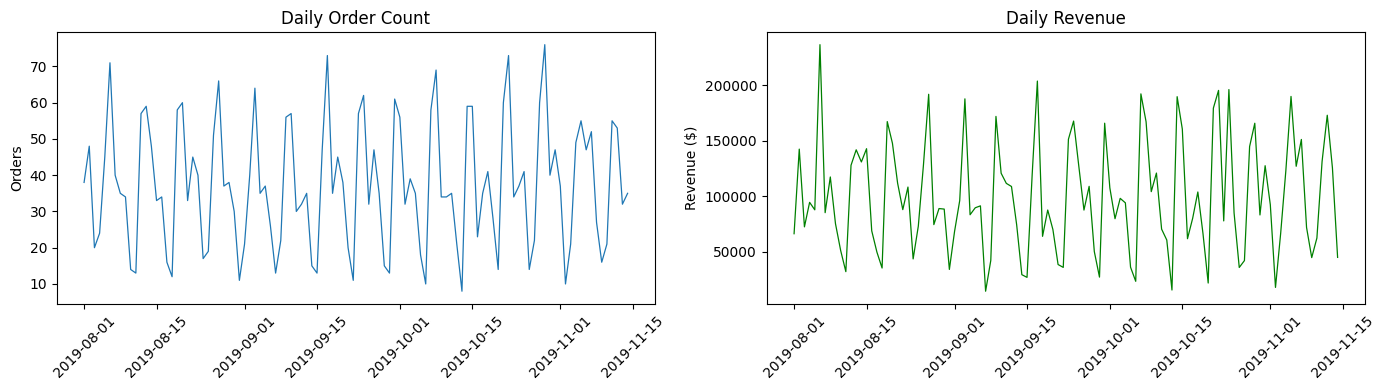


--- Top Product Categories (sales table) ---


product_category,n_rows,total_price
Rony,118,947658
Sioneer,89,640831
Opple,67,581853
Ramsung,68,474119
Zamaha,13,70534
Reagate,5,21031


In [0]:

# 1. DATA EXPLORER

import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType, StructType, StructField, StringType
import matplotlib.pyplot as plt

CAT = "databricks_simulated_retail_customer_data"

# ---- Load tables ----
orders_raw = spark.table(f"{CAT}.v01.sales_orders")
sales_raw  = spark.table(f"{CAT}.v01.sales")
customers  = spark.table(f"{CAT}.v01.customers")

print("=== DATA EXPLORER ===")
print(f"sales_orders : {orders_raw.count():,} rows")
print(f"sales        : {sales_raw.count():,} rows")
print(f"customers    : {customers.count():,} rows")

# ---- Convert epoch to date ----
orders = orders_raw.withColumn("order_date", F.to_date(F.from_unixtime("order_datetime")))

date_stats = orders.agg(
    F.min("order_date").alias("min_date"),
    F.max("order_date").alias("max_date"),
    F.countDistinct("order_date").alias("n_days")
).collect()[0]
print(f"Date range : {date_stats['min_date']} to {date_stats['max_date']} ({date_stats['n_days']} days)")

# ---- Parse ordered_products JSON ----
item_schema = ArrayType(StructType([
    StructField("curr", StringType()),
    StructField("id", StringType()),
    StructField("name", StringType()),
    StructField("price", StringType()),
    StructField("promotion_info", StringType()),
    StructField("qty", StringType()),
    StructField("unit", StringType()),
]))

orders_parsed = (
    orders
    .withColumn("items", F.from_json("ordered_products", item_schema))
    .withColumn("item", F.explode("items"))
    .withColumn("item_price", F.col("item.price").cast("double"))
    .withColumn("item_qty",   F.col("item.qty").cast("int"))
    .withColumn("line_revenue", F.col("item_price") * F.col("item_qty"))
)

print(f"Exploded line items: {orders_parsed.count():,}")

# ---- Daily aggregation ----
daily_agg = (
    orders_parsed
    .groupBy("order_date")
    .agg(
        F.countDistinct("order_number").alias("n_orders"),
        F.count("*").alias("n_items"),
        F.sum("line_revenue").alias("total_revenue"),
    )
    .orderBy("order_date")
)

daily_pd = daily_agg.toPandas()

# ---- Charts ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(daily_pd["order_date"], daily_pd["n_orders"], linewidth=0.9)
axes[0].set_title("Daily Order Count")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(daily_pd["order_date"], daily_pd["total_revenue"], linewidth=0.9, color="green")
axes[1].set_title("Daily Revenue")
axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ---- Top categories from sales table ----
print("\n--- Top Product Categories (sales table) ---")
cat_counts = sales_raw.groupBy("product_category").agg(
    F.count("*").alias("n_rows"),
    F.sum("total_price").alias("total_price")
).orderBy(F.desc("total_price")).toPandas()
display(cat_counts)

## 2. Data Validator

Tutaj sprawdzamy jakość danych wejściowych dla forecastu: braki, duplikaty, luki w szeregu czasowym, puste koszyki oraz nietypowe wartości przychodu. Celem tej sekcji jest szybkie wykrycie problemów, które mogą zniekształcić trening modeli.

In [0]:

# 2. DATA VALIDATOR

import pyspark.sql.functions as F
import numpy as np
import pandas as pd

report = []

# ---- A. Nulls in key columns ----
for tbl_name, tbl_df, key_cols in [
    ("sales_orders", orders, ["order_number", "customer_id", "order_date", "ordered_products"]),
    ("sales", sales_raw, ["customer_id", "order_date", "total_price"]),
    ("customers", customers, ["customer_id", "state", "loyalty_segment"]),
]:
    for col in key_cols:
        null_cnt = tbl_df.filter(F.col(col).isNull()).count()
        if null_cnt > 0:
            report.append(("WARNING", f"Nulls in {tbl_name}.{col}", f"{null_cnt:,} rows"))

if not any(r[0] != "PASS" for r in report):
    report.append(("PASS", "Null check", "No nulls in key columns"))

# ---- B. Duplicate order_numbers ----
dupes = orders.groupBy("order_number").count().filter(F.col("count") > 1).count()
report.append(("BLOCKER" if dupes > 0 else "PASS",
               "Duplicate order_number", f"{dupes:,} duplicates"))

# ---- C. Date gaps ----
all_dates = pd.to_datetime(daily_pd["order_date"], errors="coerce").dropna().dt.date.sort_values()
expected = set(pd.date_range(all_dates.min(), all_dates.max(), freq="D").date)
actual = set(all_dates.tolist())
missing = expected - actual
report.append(("WARNING" if missing else "PASS",
               "Date gaps in daily series", f"{len(missing)} missing days"))

# ---- D. Empty ordered_products ----
empty_prods = orders.filter(
    F.col("ordered_products").isNull() |
    (F.col("ordered_products") == "") |
    (F.col("ordered_products") == "[]")
).count()
report.append(("WARNING" if empty_prods > 0 else "PASS",
               "Empty ordered_products", f"{empty_prods:,} orders"))

# ---- E. Revenue outliers (MAD) ----
rev = daily_pd["total_revenue"].values
median_rev = np.median(rev)
mad = np.median(np.abs(rev - median_rev))
if mad > 0:
    outlier_days = int(np.sum(np.abs(rev - median_rev) / mad > 3))
else:
    outlier_days = 0
report.append(("WARNING" if outlier_days > 3 else "PASS",
               "Revenue outlier days (MAD>3)", f"{outlier_days} days"))

# ---- Print report ----
print("=== DATA VALIDATOR REPORT ===")
print(f"{'Severity':<10} {'Check':<30} {'Finding'}")
print("-" * 70)
for sev, check, finding in report:
    print(f"{sev:<10} {check:<30} {finding}")

=== DATA VALIDATOR REPORT ===
Severity   Check                          Finding
----------------------------------------------------------------------
WARNING    Nulls in sales_orders.order_date 45 rows
BLOCKER    Duplicate order_number         74 duplicates
PASS       Date gaps in daily series      0 missing days
PASS       Empty ordered_products         0 orders
PASS       Revenue outlier days (MAD>3)   2 days


## 3. Feature Advisor

W tej części budujemy cechy do modelowania: agregaty dzienne, cechy kalendarzowe, lagi, rolling statistics oraz wzbogacenie o informacje o klientach. Na końcu sprawdzamy, które zmienne są najmocniej powiązane z targetem `n_orders`.

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


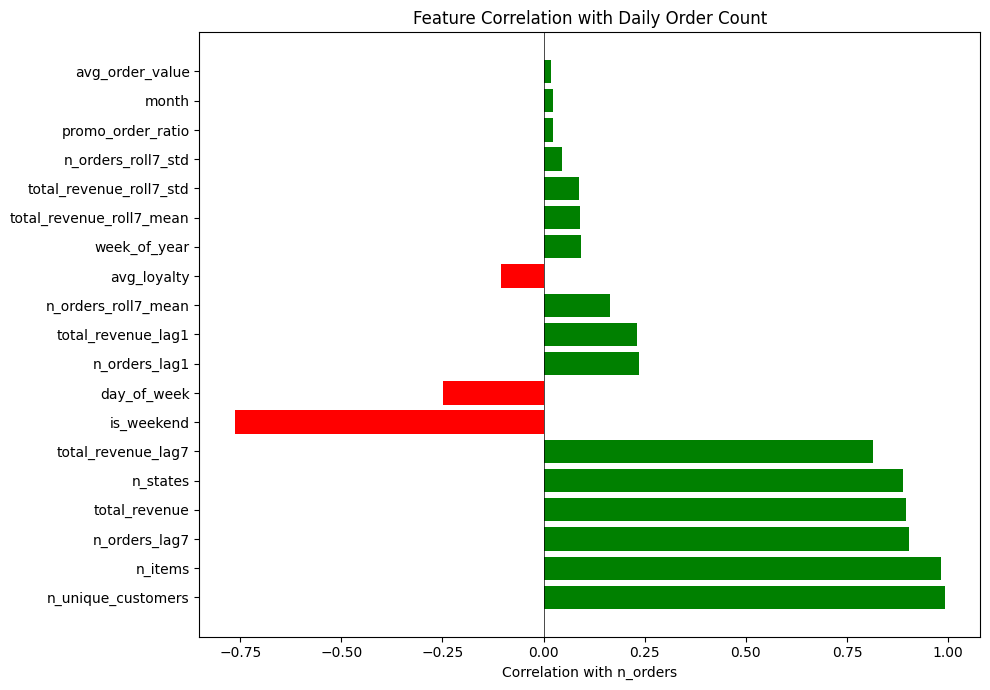


Dataset shape: (106, 21)
Features: 19

Top 5 correlated features:
  n_unique_customers             +0.991
  n_items                        +0.983
  n_orders_lag7                  +0.904
  total_revenue                  +0.895
  n_states                       +0.888


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:

# 3. FEATURE ADVISOR

import pyspark.sql.functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

# ---- Daily series from sales_orders ----
has_promo = F.when(F.col("promo_info").isNotNull() & (F.col("promo_info") != "[]"), 1).otherwise(0)

daily_features_sp = (
    orders
    .withColumn("has_promo", has_promo)
    .groupBy("order_date")
    .agg(
        F.countDistinct("order_number").alias("n_orders"),
        F.sum("number_of_line_items").alias("n_items"),
        F.countDistinct("customer_id").alias("n_unique_customers"),
        F.mean("has_promo").alias("promo_order_ratio"),
    )
    .orderBy("order_date")
)

# ---- Compute total_revenue from parsed items ----
rev_daily = (
    orders_parsed
    .groupBy("order_date")
    .agg(F.sum("line_revenue").alias("total_revenue"))
)

daily_features_sp = daily_features_sp.join(rev_daily, "order_date")
daily_features_sp = daily_features_sp.withColumn(
    "avg_order_value", F.col("total_revenue") / F.col("n_orders")
)

# ---- Calendar features ----
daily_features_sp = (
    daily_features_sp
    .withColumn("day_of_week", F.dayofweek("order_date"))
    .withColumn("is_weekend", F.when(F.dayofweek("order_date").isin(1, 7), 1).otherwise(0))
    .withColumn("week_of_year", F.weekofyear("order_date"))
    .withColumn("month", F.month("order_date"))
)

# ---- Lag and rolling features ----
w = Window.orderBy("order_date")
for target_col in ["n_orders", "total_revenue"]:
    daily_features_sp = (
        daily_features_sp
        .withColumn(f"{target_col}_lag1", F.lag(target_col, 1).over(w))
        .withColumn(f"{target_col}_lag7", F.lag(target_col, 7).over(w))
    )

w7 = Window.orderBy("order_date").rowsBetween(-6, 0)
for target_col in ["n_orders", "total_revenue"]:
    daily_features_sp = (
        daily_features_sp
        .withColumn(f"{target_col}_roll7_mean", F.avg(target_col).over(w7))
        .withColumn(f"{target_col}_roll7_std",  F.stddev(target_col).over(w7))
    )

# ---- Customer enrichment per day ----
cust_enrich = (
    orders
    .join(customers.select("customer_id", "state", "loyalty_segment"), "customer_id", "left")
    .groupBy("order_date")
    .agg(
        F.countDistinct("state").alias("n_states"),
        F.avg("loyalty_segment").alias("avg_loyalty"),
    )
)
daily_features_sp = daily_features_sp.join(cust_enrich, "order_date", "left")

# ---- Convert to pandas ----
df = daily_features_sp.orderBy("order_date").toPandas()
df["order_date"] = pd.to_datetime(df["order_date"])

# ---- Correlation with target ----
target = "n_orders"
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]
corr = df[numeric_cols + [target]].corr()[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["green" if c > 0 else "red" for c in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.set_xlabel(f"Correlation with {target}")
ax.set_title("Feature Correlation with Daily Order Count")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nDataset shape: {df.shape}")
print(f"Features: {len(numeric_cols)}")
print(f"\nTop 5 correlated features:")
for feat, val in corr.head(5).items():
    print(f"  {feat:30s} {val:+.3f}")

## 4. Forecast Runner

Tutaj uruchamiamy porównanie modeli. Najpierw liczone są baseline'y, potem trenowany jest model LightGBM na przygotowanych cechach, a na końcu porównywane są metryki jakości i logowany jest eksperyment w MLflow.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Train: 85 days (2019-08-08 to 2019-10-31)
Test : 14 days (2019-11-01 to 2019-11-14)

=== FORECAST RUNNER RESULTS ===


Model,WMAPE,Bias,Forecast Accuracy
Naive,0.403921568627451,0.2901960784313726,0.596078431372549
7-day MA,0.3876750700280112,0.17647058823529413,0.6123249299719888
Seasonal Naive,0.23137254901960785,0.17647058823529413,0.7686274509803921
LightGBM,0.09701299022042661,0.047195928569346984,0.9029870097795734


2026/09/23 15:20:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405615837166522.2.azuredatabricks.net/ml/experiments/4406744677905283/models/m-459710709b8a4cfd97cbef52f288216a?o=7405615837166522
2026/09/23 15:21:00 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.



MLflow run_id: a202d998f1c74447a0b078461768f0bd


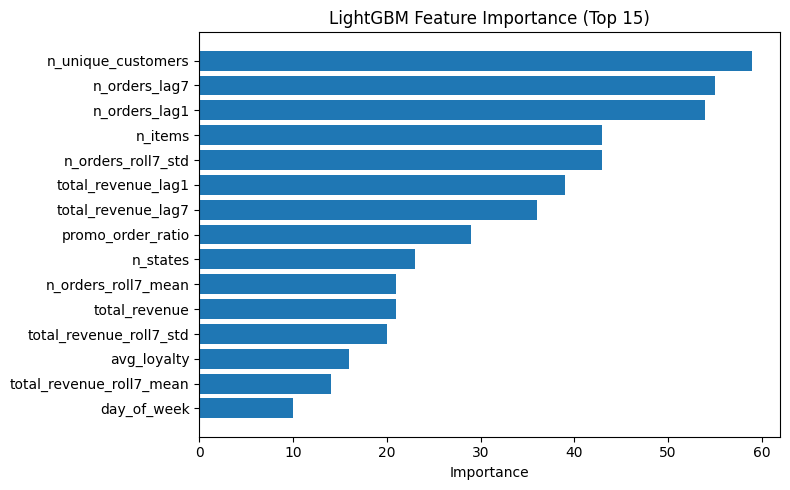

In [0]:

# 4. FORECAST RUNNER

%pip install lightgbm -q
import lightgbm as lgb
import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt

# ---- Prepare ----
target = "n_orders"
feature_cols = [
    "n_items", "total_revenue", "avg_order_value",
    "n_unique_customers", "promo_order_ratio",
    "day_of_week", "is_weekend", "week_of_year", "month",
    "n_orders_lag1", "n_orders_lag7",
    "total_revenue_lag1", "total_revenue_lag7",
    "n_orders_roll7_mean", "n_orders_roll7_std",
    "total_revenue_roll7_mean", "total_revenue_roll7_std",
    "n_states", "avg_loyalty",
]
available = [c for c in feature_cols if c in df.columns]
df_model = df.dropna(subset=available + [target]).copy()

# ---- Time split: last 14 days as holdout ----
cutoff = df_model["order_date"].max() - pd.Timedelta(days=14)
train = df_model[df_model["order_date"] <= cutoff]
test  = df_model[df_model["order_date"] > cutoff]
print(f"Train: {len(train)} days ({train['order_date'].min().date()} to {train['order_date'].max().date()})")
print(f"Test : {len(test)} days ({test['order_date'].min().date()} to {test['order_date'].max().date()})")

X_train, y_train = train[available].fillna(0), train[target]
X_test,  y_test  = test[available].fillna(0),  test[target]

# ---- Baselines ----
def calc_metrics(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = ~np.isnan(predicted) & ~np.isnan(actual)
    a, p = actual[mask], predicted[mask]
    wmape = np.sum(np.abs(a - p)) / np.sum(a) if np.sum(a) > 0 else np.nan
    bias  = np.sum(p - a) / np.sum(a) if np.sum(a) > 0 else np.nan
    return wmape, bias, 1 - wmape

results = []

# Naive: last train value
naive_pred = np.full(len(test), y_train.iloc[-1])
results.append(("Naive", *calc_metrics(y_test, naive_pred)))

# 7-day MA
ma7_val = y_train.tail(7).mean()
results.append(("7-day MA", *calc_metrics(y_test, np.full(len(test), ma7_val))))

# Seasonal naive (same DOW previous week)
test_dow = test["day_of_week"].values
train_tmp = train.set_index("order_date")
snaive_pred = []
for _, row in test.iterrows():
    same_dow = train_tmp[train_tmp["day_of_week"] == row["day_of_week"]][target]
    snaive_pred.append(same_dow.iloc[-1] if len(same_dow) > 0 else ma7_val)
results.append(("Seasonal Naive", *calc_metrics(y_test, snaive_pred)))

# ---- LightGBM ----
lgb_model = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test).clip(min=0)
results.append(("LightGBM", *calc_metrics(y_test, lgb_pred)))

# ---- Results table ----
results_df = pd.DataFrame(results, columns=["Model", "WMAPE", "Bias", "Forecast Accuracy"])
print("\n=== FORECAST RUNNER RESULTS ===")
display(results_df)

# ---- MLflow logging ----
mlflow.set_experiment(f"/Users/katarzyna.palach@cloudsonmars.com/marketplace_retail_forecast")
with mlflow.start_run(run_name="lgb_daily_orders") as run:
    mlflow.log_params({
        "model_type": "LightGBM",
        "target": target,
        "features": str(available),
        "train_days": len(train),
        "test_days": len(test),
    })
    for _, row in results_df.iterrows():
        mlflow.log_metric(f"wmape_{row['Model'].replace(' ','_').replace('-','')}", row["WMAPE"])
        mlflow.log_metric(f"bias_{row['Model'].replace(' ','_').replace('-','')}", row["Bias"])
    mlflow.sklearn.log_model(lgb_model, artifact_path="model")
    run_id = run.info.run_id
    print(f"\nMLflow run_id: {run_id}")

# ---- Feature importance ----
imp = pd.DataFrame({"feature": available, "importance": lgb_model.feature_importances_})
imp = imp.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"], imp["importance"])
ax.set_xlabel("Importance")
ax.set_title("LightGBM Feature Importance (Top 15)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Results Explainer

Ta sekcja pokazuje, jak zachowuje się najlepszy model na zbiorze holdout. Rozbijamy błąd po dniach tygodnia i weekendach, wskazujemy najtrudniejsze dni oraz wizualnie porównujemy wartości rzeczywiste z predykcjami.

=== RESULTS EXPLAINER ===

--- Error by Day of Week ---
  Monday        WMAPE=0.0093  Bias=+0.0093  n=2
  Tuesday       WMAPE=0.1106  Bias=+0.1106  n=2
  Wednesday     WMAPE=0.0650  Bias=+0.0428  n=2
  Thursday      WMAPE=0.1105  Bias=+0.1105  n=2
  Friday        WMAPE=0.0750  Bias=+0.0301  n=2
  Saturday      WMAPE=0.3118  Bias=+0.1981  n=2
  Sunday        WMAPE=0.2121  Bias=-0.2121  n=2

--- Error: Weekday vs Weekend ---
  Weekday     WMAPE=0.0734  Bias=+0.0630  n=10
  Weekend     WMAPE=0.2502  Bias=-0.0552  n=4

--- Largest Errors ---
  2019-11-12 (Tuesday  )  actual=53  pred=61.9  error=8.9
  2019-11-10 (Sunday   )  actual=21  pred=14.4  error=6.6
  2019-11-02 (Saturday )  actual=10  pred=16.6  error=6.6


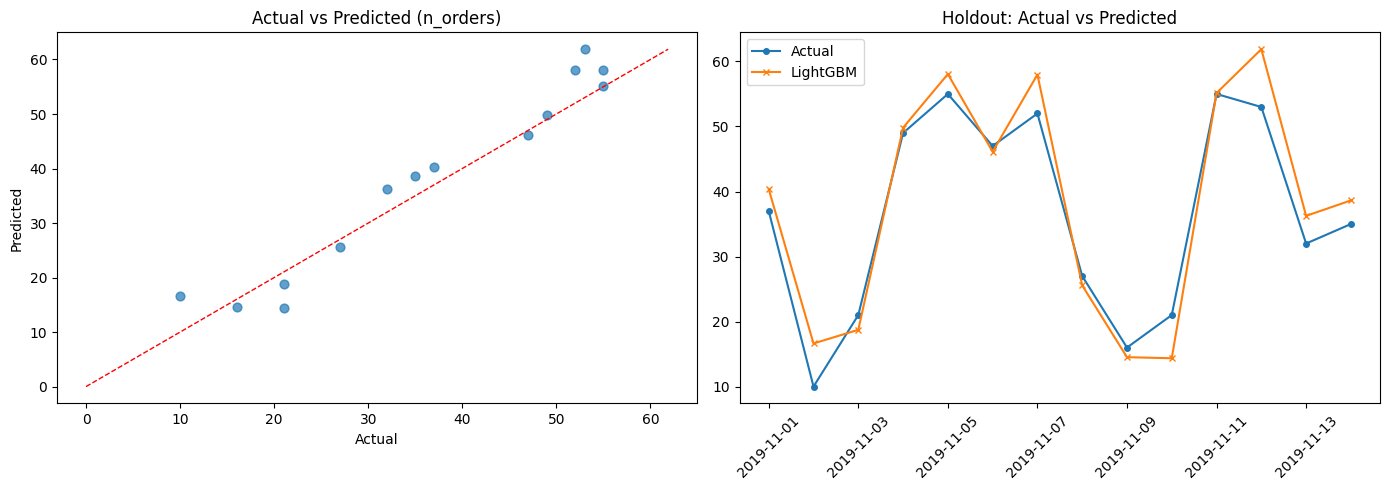

In [0]:

# 5. RESULTS EXPLAINER

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test_res = test.copy()
test_res["predicted"] = lgb_pred
test_res["error"] = np.abs(test_res[target] - test_res["predicted"])
test_res["day_name"] = test_res["order_date"].dt.day_name()
test_res["wknd"] = test_res["is_weekend"].map({0: "Weekday", 1: "Weekend"})

# ---- Breakdown by day of week ----
def wmape(a, p):
    return np.sum(np.abs(a - p)) / np.sum(a) if np.sum(a) > 0 else np.nan
def bias_fn(a, p):
    return np.sum(p - a) / np.sum(a) if np.sum(a) > 0 else np.nan

print("=== RESULTS EXPLAINER ===")
print("\n--- Error by Day of Week ---")
for dow in ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]:
    sub = test_res[test_res["day_name"] == dow]
    if len(sub) > 0:
        w = wmape(sub[target].values, sub["predicted"].values)
        b = bias_fn(sub[target].values, sub["predicted"].values)
        print(f"  {dow:12s}  WMAPE={w:.4f}  Bias={b:+.4f}  n={len(sub)}")

print("\n--- Error: Weekday vs Weekend ---")
for grp in ["Weekday", "Weekend"]:
    sub = test_res[test_res["wknd"] == grp]
    if len(sub) > 0:
        w = wmape(sub[target].values, sub["predicted"].values)
        b = bias_fn(sub[target].values, sub["predicted"].values)
        print(f"  {grp:10s}  WMAPE={w:.4f}  Bias={b:+.4f}  n={len(sub)}")

# ---- Worst days ----
print("\n--- Largest Errors ---")
worst = test_res.nlargest(3, "error")[["order_date", "day_name", target, "predicted", "error"]]
for _, r in worst.iterrows():
    print(f"  {r['order_date'].date()} ({r['day_name']:9s})  actual={r[target]:.0f}  pred={r['predicted']:.1f}  error={r['error']:.1f}")

# ---- Charts ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(test_res[target], test_res["predicted"], alpha=0.7, s=40)
max_v = max(test_res[target].max(), test_res["predicted"].max())
axes[0].plot([0, max_v], [0, max_v], "r--", linewidth=1)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (n_orders)")

# Time series
axes[1].plot(test_res["order_date"], test_res[target], label="Actual", marker="o", markersize=4)
axes[1].plot(test_res["order_date"], test_res["predicted"], label="LightGBM", marker="x", markersize=4)
axes[1].set_title("Holdout: Actual vs Predicted")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Business Recommender

Na końcu przekładamy wynik modelowania na decyzje biznesowe. Sekcja podsumowuje zwycięski model, formułuje rekomendacje operacyjne oraz pokazuje, jak zarejestrować i odpytać champion model dla kolejnego dnia.

In [0]:

# 6. BUSINESS RECOMMENDER

import pandas as pd
import numpy as np
import mlflow
from mlflow.models import infer_signature

print("=" * 70)
print("BUSINESS RECOMMENDER")
print("=" * 70)

# ---- Headline ----
lgb_row = results_df[results_df["Model"] == "LightGBM"].iloc[0]
baseline_best = results_df[results_df["Model"] != "LightGBM"].sort_values("WMAPE").iloc[0]
best_model_name = results_df.sort_values("WMAPE").iloc[0]["Model"]
improvement = (baseline_best["WMAPE"] - lgb_row["WMAPE"]) * 100

print(f"\n--- HEADLINE ---")
if lgb_row["WMAPE"] < baseline_best["WMAPE"]:
    print(f"LightGBM beats the best baseline ({baseline_best['Model']}) by {improvement:.1f} WMAPE points.")
else:
    print(f"LightGBM does NOT beat the best baseline ({baseline_best['Model']}).")
print(f"LightGBM WMAPE: {lgb_row['WMAPE']:.3f} ({lgb_row['Forecast Accuracy']*100:.1f}% forecast accuracy)")
print(f"Best baseline : {baseline_best['WMAPE']:.3f} ({baseline_best['Model']})")
print(f"Champion model: {best_model_name}")

# ---- Recommendations ----
print(f"""
--- 3 RECOMMENDATIONS ---
1. Staffing & logistics: Use next-day order predictions to adjust warehouse
   staffing and delivery capacity 24h ahead. Even a rough count beats reacting
   after the fact.

2. Inventory replenishment: The model picks up weekly rhythm and promo effects.
   Feed predictions into reorder-point logic for fast-moving SKUs.

3. Marketing spend timing: Schedule campaigns on predicted low-order days to
   smooth demand, reducing peaks that strain fulfillment.

--- LIMITATIONS ---
- Only 106 days of history. No full seasonal cycle (Aug–Nov 2019 only).
- Single Marketplace sample dataset, not production data.
- Daily grain hides intra-day patterns. Hourly would improve staffing.
- No external signals (holidays, weather, competitor promos) in this dataset.
""")

# ---- Register champion model when possible ----
print("--- MODEL REGISTRY ---")
model_uri = None

if best_model_name == "LightGBM":
    input_example = X_train.head(5).copy()
    signature = infer_signature(input_example, lgb_model.predict(input_example))

    with mlflow.start_run(run_name="lgb_daily_orders_signed") as reg_run:
        mlflow.sklearn.log_model(
            lgb_model,
            name="model",
            signature=signature,
            input_example=input_example,
        )
        signed_run_id = reg_run.info.run_id

    model_uri = f"runs:/{signed_run_id}/model"
    reg = mlflow.register_model(model_uri, "sandbox.default.marketplace_retail_daily_orders")
    print(f"Registered model: {reg.name}, version: {reg.version}")
else:
    print(f"Champion model is '{best_model_name}'. Registry step skipped because this winner is a rule-based baseline.")

# ---- Champion model query demo ----
print("\n--- CHAMPION MODEL QUERY ---")
last_row = df_model.iloc[-1]
next_day_features = last_row[available].to_frame().T.fillna(0).infer_objects(copy=False)
next_date = last_row["order_date"] + pd.Timedelta(days=1)
next_day_features["day_of_week"] = next_date.dayofweek + 1
next_day_features["is_weekend"] = 1 if next_date.dayofweek >= 5 else 0
next_day_features["month"] = next_date.month
next_day_features["week_of_year"] = next_date.isocalendar()[1]

if best_model_name == "LightGBM":
    loaded_model = mlflow.sklearn.load_model(model_uri)
    prediction = float(loaded_model.predict(next_day_features)[0])
elif best_model_name == "Naive":
    prediction = float(y_train.iloc[-1])
elif best_model_name == "7-day MA":
    prediction = float(y_train.tail(7).mean())
elif best_model_name == "Seasonal Naive":
    next_dow = int(next_day_features["day_of_week"].iloc[0])
    same_dow = df_model[df_model["day_of_week"] == next_dow][target]
    fallback = float(y_train.tail(7).mean())
    prediction = float(same_dow.iloc[-1]) if len(same_dow) > 0 else fallback
else:
    raise ValueError(f"Unsupported champion model: {best_model_name}")

print(f"Champion model used for scoring: {best_model_name}")
print(f"Prediction for {next_date.date()}: {prediction:.0f} orders")

print("\n" + "=" * 70)
print("END OF SKILLS PIPELINE")
print("=" * 70)

BUSINESS RECOMMENDER

--- HEADLINE ---
LightGBM beats the best baseline (Seasonal Naive) by 13.4 WMAPE points.
LightGBM WMAPE: 0.097 (90.3% forecast accuracy)
Best baseline : 0.231 (Seasonal Naive)
Champion model: LightGBM

--- 3 RECOMMENDATIONS ---
1. Staffing & logistics: Use next-day order predictions to adjust warehouse
   staffing and delivery capacity 24h ahead. Even a rough count beats reacting
   after the fact.

2. Inventory replenishment: The model picks up weekly rhythm and promo effects.
   Feed predictions into reorder-point logic for fast-moving SKUs.

3. Marketing spend timing: Schedule campaigns on predicted low-order days to
   smooth demand, reducing peaks that strain fulfillment.

--- LIMITATIONS ---
- Only 106 days of history. No full seasonal cycle (Aug–Nov 2019 only).
- Single Marketplace sample dataset, not production data.
- Daily grain hides intra-day patterns. Hourly would improve staffing.
- No external signals (holidays, weather, competitor promos) in this d

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405615837166522.2.azuredatabricks.net/ml/experiments/4406744677905283/models/m-82a581d9ba024a268c42920d179f8688?o=7405615837166522
Registered model 'sandbox.default.marketplace_retail_daily_orders' alrea

Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '3' of model 'sandbox.default.marketplace_retail_daily_orders': https://adb-7405615837166522.2.azuredatabricks.net/explore/data/models/sandbox/default/marketplace_retail_daily_orders/version/3?o=7405615837166522


Registered model: sandbox.default.marketplace_retail_daily_orders, version: 3

--- CHAMPION MODEL QUERY ---


/home/spark-26203088-24f2-4437-9f2b-4d/.ipykernel/71/command-5159638804480054-872129583:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  next_day_features = last_row[available].to_frame().T.fillna(0).infer_objects(copy=False)


Champion model used for scoring: LightGBM
Prediction for 2019-11-15: 39 orders

END OF SKILLS PIPELINE


## 7. Model Query

Ta sekcja pozwala odpytać zarejestrowany champion model z Unity Catalog. Ładujemy najnowszą wersję modelu `sandbox.default.marketplace_retail_daily_orders`, budujemy cechy dla kolejnych N dni i generujemy prognozę **z przedziałami ufności** (10–90 percentyl via LightGBM quantile regression). Można tu zmieniać horyzont (`FORECAST_DAYS`) i eksperymentować z parametrami wejściowymi.

Ustawiono alias Champion -> wersja 3


Model załadowany: sandbox.default.marketplace_retail_daily_orders@Champion
Trenowanie modeli quantile (p10, p90)...
Modele quantile gotowe.
Ostatni znany dzień: 2019-11-14
Prognoza na: 7 dni do przodu

=== PROGNOZA CHAMPION MODELU (z przedziałami ufności 80%) ===
Data           Dzień          P10  Pred   P90
----------------------------------------------------
2019-11-15     Friday          33    33    33
2019-11-16     Saturday        31    32    33
2019-11-17     Sunday          31    32    33
2019-11-18     Monday          34    38    36
2019-11-19     Tuesday         36    38    35
2019-11-20     Wednesday       33    32    33
2019-11-21     Thursday        31    33    33

Średnia dzienna: 34 zamówień
Suma 7 dni:     238 zamówień
Rozrzut (P90-P10): ±0 zam./dzień średnio


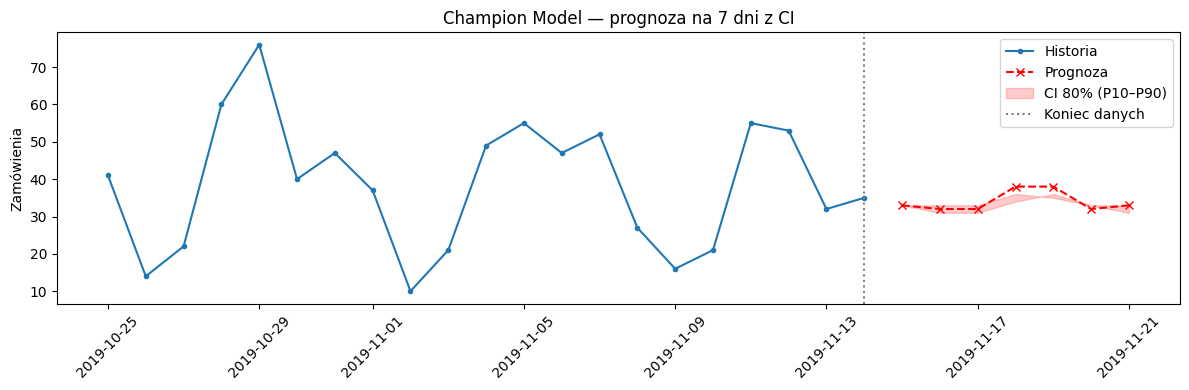

In [0]:

# 7. MODEL QUERY — odpytanie champion modelu z rejestru + confidence intervals

import mlflow
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# ---- Konfiguracja ----
FORECAST_DAYS = 7          # ile dni do przodu prognozować
MODEL_NAME = "sandbox.default.marketplace_retail_daily_orders"

# ---- Ustaw alias Champion i załaduj z Unity Catalog ----
from mlflow import MlflowClient
client = MlflowClient()

versions = client.search_model_versions(f"name='{MODEL_NAME}'")
latest = max(versions, key=lambda v: int(v.version))
client.set_registered_model_alias(MODEL_NAME, "Champion", latest.version)
print(f"Ustawiono alias Champion -> wersja {latest.version}")

champion = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@Champion")
print(f"Model załadowany: {MODEL_NAME}@Champion")

# ---- Trenuj modele quantile dla przedziałów ufności (10% / 90%) ----
print("Trenowanie modeli quantile (p10, p90)...")
lgb_q10 = lgb.LGBMRegressor(
    objective="quantile", alpha=0.10,
    n_estimators=200, learning_rate=0.05, max_depth=6, verbose=-1, random_state=42
)
lgb_q90 = lgb.LGBMRegressor(
    objective="quantile", alpha=0.90,
    n_estimators=200, learning_rate=0.05, max_depth=6, verbose=-1, random_state=42
)
lgb_q10.fit(X_train, y_train)
lgb_q90.fit(X_train, y_train)
print("Modele quantile gotowe.")

# ---- Buduj cechy dla kolejnych dni ----
# Punkt startowy: ostatni znany dzień z datasetu
last = df_model.iloc[-1]
last_date = last["order_date"]
print(f"Ostatni znany dzień: {last_date.date()}")
print(f"Prognoza na: {FORECAST_DAYS} dni do przodu\n")

forecast_rows = []
rolling_history = df_model[available + ["order_date", target]].tail(14).copy()

for i in range(1, FORECAST_DAYS + 1):
    fdate = last_date + pd.Timedelta(days=i)
    row = {}

    # Lag features — z historii + wcześniejszych predykcji
    hist = rolling_history.tail(14)
    row["n_orders_lag1"] = float(hist[target].iloc[-1]) if len(hist) >= 1 else 0
    row["n_orders_lag7"] = float(hist[target].iloc[-7]) if len(hist) >= 7 else 0
    row["n_orders_roll7_mean"] = float(hist[target].tail(7).mean())
    row["n_orders_roll7_std"] = float(hist[target].tail(7).std())

    # Revenue lags — przybliżamy z ostatnich znanych
    if "total_revenue" in hist.columns:
        row["total_revenue_lag1"] = float(hist["total_revenue"].iloc[-1]) if len(hist) >= 1 else 0
        row["total_revenue_lag7"] = float(hist["total_revenue"].iloc[-7]) if len(hist) >= 7 else 0
        row["total_revenue_roll7_mean"] = float(hist["total_revenue"].tail(7).mean())
        row["total_revenue_roll7_std"] = float(hist["total_revenue"].tail(7).std())

    # Cechy kopiowane z ostatniego dnia (stabilne w krótkim horyzoncie)
    for col in ["n_items", "total_revenue", "avg_order_value",
                "n_unique_customers", "promo_order_ratio", "n_states", "avg_loyalty"]:
        if col not in row and col in available:
            row[col] = float(last[col]) if pd.notna(last[col]) else 0

    # Cechy kalendarzowe
    row["day_of_week"] = fdate.isoweekday()  # 1=Mon..7=Sun (Spark convention)
    row["is_weekend"] = 1 if fdate.weekday() >= 5 else 0
    row["week_of_year"] = fdate.isocalendar()[1]
    row["month"] = fdate.month

    # Predykcja — wymuszenie typów zgodnych ze schemą modelu
    input_df = pd.DataFrame([{c: row.get(c, 0) for c in available}])
    # long (int64) w schemacie
    for ic in ["n_items", "n_unique_customers", "n_states"]:
        if ic in input_df.columns:
            input_df[ic] = input_df[ic].astype("int64")
    # integer (int32) w schemacie — Spark int -> pandas int32
    for ic in ["day_of_week", "is_weekend", "week_of_year", "month"]:
        if ic in input_df.columns:
            input_df[ic] = input_df[ic].astype("int32")
    pred = float(champion.predict(input_df)[0])
    pred = max(pred, 0)
    lo = max(float(lgb_q10.predict(input_df.astype(float))[0]), 0)
    hi = max(float(lgb_q90.predict(input_df.astype(float))[0]), 0)

    row[target] = pred
    row["lower_bound"] = lo
    row["upper_bound"] = hi
    row["order_date"] = fdate
    forecast_rows.append(row)

    # Dodaj do historii dla kolejnych lagów
    new_hist_row = last.copy()
    new_hist_row["order_date"] = fdate
    new_hist_row[target] = pred
    for k, v in row.items():
        if k in new_hist_row.index:
            new_hist_row[k] = v
    rolling_history = pd.concat([rolling_history, new_hist_row.to_frame().T], ignore_index=True)

# ---- Wyniki ----
forecast_df = pd.DataFrame(forecast_rows)
forecast_df["order_date"] = pd.to_datetime(forecast_df["order_date"])
forecast_df["day_name"] = forecast_df["order_date"].dt.day_name()
forecast_df["predicted_orders"] = forecast_df[target].round(0).astype(int)
forecast_df["lower"] = forecast_df["lower_bound"].round(0).astype(int)
forecast_df["upper"] = forecast_df["upper_bound"].round(0).astype(int)

print("=== PROGNOZA CHAMPION MODELU (z przedziałami ufności 80%) ===")
print(f"{'Data':<14} {'Dzień':<12} {'P10':>5} {'Pred':>5} {'P90':>5}")
print("-" * 52)
for _, r in forecast_df.iterrows():
    print(f"{r['order_date'].date()!s:<14} {r['day_name']:<12} {r['lower']:>5} {r['predicted_orders']:>5} {r['upper']:>5}")

print(f"\nŚrednia dzienna: {forecast_df['predicted_orders'].mean():.0f} zamówień")
print(f"Suma {FORECAST_DAYS} dni:     {forecast_df['predicted_orders'].sum()} zamówień")
print(f"Rozrzut (P90-P10): ±{(forecast_df['upper'] - forecast_df['lower']).mean()/2:.0f} zam./dzień średnio")

# ---- Wykres: historia + prognoza ----
fig, ax = plt.subplots(figsize=(12, 4))
hist_tail = df_model.tail(21)
ax.plot(hist_tail["order_date"], hist_tail[target], label="Historia", marker="o", markersize=3)
ax.plot(forecast_df["order_date"], forecast_df["predicted_orders"],
        label="Prognoza", marker="x", markersize=6, color="red", linestyle="--")
ax.fill_between(forecast_df["order_date"], forecast_df["lower"], forecast_df["upper"],
                alpha=0.2, color="red", label="CI 80% (P10–P90)")
ax.axvline(last_date, color="gray", linestyle=":", label="Koniec danych")
ax.set_title(f"Champion Model — prognoza na {FORECAST_DAYS} dni z CI")
ax.set_ylabel("Zamówienia")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Komentarz biznesowy + klasyfikacja

Ostatnia sekcja generuje raport biznesowy i rekomendacje staffingowe **wyłącznie na podstawie predykcji champion modelu** — bez wywołań LLM. Progi klasyfikacji (P25/mediana/P75) pochodzą z rozkładu danych treningowych, a komentarz budowany jest szablonem na wynikach z sekcji 7.

In [0]:

# 8. Komentarz biznesowy + klasyfikacja staffingu
#    Całość oparta na predykcjach champion modelu — bez LLM

import pandas as pd
import numpy as np

# ---- Progi z rozkładu danych treningowych ----
train_median = float(df_model[target].median())
train_p75 = float(df_model[target].quantile(0.75))
train_p25 = float(df_model[target].quantile(0.25))
train_mean = float(df_model[target].mean())

# ---- Klasyfikacja staffingu ----
def classify_staffing(row):
    pred = row["predicted_orders"]
    is_wknd = row["day_name"] in ("Saturday", "Sunday")
    if pred >= train_p75 or (is_wknd and pred >= train_median):
        return "extra_staffing_needed"
    elif pred <= train_p25 and not is_wknd:
        return "reduced_staffing_ok"
    else:
        return "normal_staffing"

staffing_df = forecast_df[["order_date", "day_name", "predicted_orders", "lower", "upper"]].copy()
staffing_df["staffing_recommendation"] = staffing_df.apply(classify_staffing, axis=1)

# ---- Komentarz biznesowy ----
total = int(staffing_df["predicted_orders"].sum())
avg_daily = staffing_df["predicted_orders"].mean()
peak = staffing_df.loc[staffing_df["predicted_orders"].idxmax()]
low = staffing_df.loc[staffing_df["predicted_orders"].idxmin()]
ci_spread = (staffing_df["upper"] - staffing_df["lower"]).mean()
extra_days = staffing_df[staffing_df["staffing_recommendation"] == "extra_staffing_needed"]["day_name"].tolist()
reduced_days = staffing_df[staffing_df["staffing_recommendation"] == "reduced_staffing_ok"]["day_name"].tolist()

trend = "stabilna" if abs(avg_daily - train_mean) / train_mean < 0.1 else (
    "wzrostowa" if avg_daily > train_mean else "spadkowa"
)
ci_pct = ci_spread / avg_daily * 100 if avg_daily > 0 else 0
ci_desc = "wąski (pewna prognoza)" if ci_pct < 15 else (
    "umiarkowany" if ci_pct < 30 else "szeroki (większa niepewność)"
)

print("=" * 70)
print("KOMENTARZ BIZNESOWY (champion model + reguły, bez LLM)")
print("=" * 70)
print(f"""
PROGNOZA: {staffing_df['order_date'].min().strftime('%d.%m')} – {staffing_df['order_date'].max().strftime('%d.%m.%Y')}

1. TREND: {total} zamówień na {len(staffing_df)} dni (śr. {avg_daily:.0f}/dzień).
   Tendencja: {trend} (historyczna średnia: {train_mean:.0f}/dzień).

2. PERSONEL:
   Szczyt: {peak['day_name']} ({int(peak['predicted_orders'])} zam.)
   Minimum: {low['day_name']} ({int(low['predicted_orders'])} zam.)
   Extra staffing: {', '.join(extra_days) if extra_days else 'brak'}.
   Redukcja: {', '.join(reduced_days) if reduced_days else 'brak'}.

3. PEWNOŚĆ: CI ±{ci_spread/2:.0f} zam./dzień ({ci_desc}).
   Progi klasyfikacji: P25={train_p25:.0f}, mediana={train_median:.0f}, P75={train_p75:.0f}.
""")

print("--- TABELA PROGNOZ Z KLASYFIKACJĄ ---")
display(spark.createDataFrame(staffing_df))

KOMENTARZ BIZNESOWY (champion model + reguły, bez LLM)

PROGNOZA: 15.11 – 21.11.2019

1. TREND: 238 zamówień na 7 dni (śr. 34/dzień).
   Tendencja: stabilna (historyczna średnia: 37/dzień).

2. PERSONEL:
   Szczyt: Monday (38 zam.)
   Minimum: Saturday (32 zam.)
   Extra staffing: brak.
   Redukcja: brak.

3. PEWNOŚĆ: CI ±0 zam./dzień (wąski (pewna prognoza)).
   Progi klasyfikacji: P25=22, mediana=35, P75=52.

--- TABELA PROGNOZ Z KLASYFIKACJĄ ---


order_date,day_name,predicted_orders,lower,upper,staffing_recommendation
2019-11-15T00:00:00.000Z,Friday,33,33,33,normal_staffing
2019-11-16T00:00:00.000Z,Saturday,32,31,33,normal_staffing
2019-11-17T00:00:00.000Z,Sunday,32,31,33,normal_staffing
2019-11-18T00:00:00.000Z,Monday,38,34,36,normal_staffing
2019-11-19T00:00:00.000Z,Tuesday,38,36,35,normal_staffing
2019-11-20T00:00:00.000Z,Wednesday,32,33,33,normal_staffing
2019-11-21T00:00:00.000Z,Thursday,33,31,33,normal_staffing
